In [ ]:
import ase.io
import matplotlib.pyplot as plt
from ase.io import read
from fairchem.core.datasets.ase_datasets import AseDBDataset
from get_calc import get_uma_calc
import numpy as np

In [ ]:
# Load Teacher Forces and Dataset
config = {
    "src": "/data/ishan-amin/OMOL/electrolytes_application/all_lmdbs/per_system/napf6_dme/train"
}

teacher_labels_folder =  "/data/ishan-amin/OMOL/electrolytes_application/all_lmdbs/per_system/napf6_dme/labels"


train_dataset = AseDBDataset(config, dataset_type="train")
train_forces_dataset = LmdbDataset(os.path.join(config['teacher_labels_folder'], 'train_forces'), dtype=np.float32, div_2=False)


    print("Loading calculator...")
    calc = get_uma_calc("/data/ishan-amin/OMOL/ESEN_OMol_ckpts/uma-s-1p1.pt")
    for idx in range(10):
        # datapoint = train_dataset[idx + 1]
        data_atoms = train_dataset.get_atoms(idx) 
        calc.calculate(data_atoms)
        output_forces = calc.results['forces'].copy()
        stored_forces  = train_forces_dataset[idx + 1].reshape(-1, 3).numpy()
        breakpoint()
        print("CALC FORCE DIFF:", np.abs((output_forces - stored_forces )).mean())
        print("TRUE FORCE DIFF:", np.abs((train_dataset[idx].forces.numpy() - stored_forces )).mean() )

In [13]:
# Load Trajectory, get calculator energies and forces
# Load xyz file
i = 20  # example: 11th structure
# path = '/data/ishan-amin/OMOL/electrolytes_application/all_trajs_min50ps/md_omol_napf6_dme_re1.traj'
path = '/data/ishan-amin/OMOL/electrolytes_application/all_trajs_min50ps/md_omol_naotf_dme_s1p1_omol.traj'
atoms = read(path, index=i)
true_forces = atoms.get_forces().copy()
calc = get_uma_calc("/data/ishan-amin/OMOL/ESEN_OMol_ckpts/uma-s-1p1.pt")
calc.calculate(atoms)
calc_forces = calc.results['forces'].copy()
print(np.abs(true_forces - calc_forces).mean())


2.4247152630718725e-07


In [6]:
# Load AseDBDataset
a2g_args = {  
    "r_energy": True,
    "r_forces": True,
    "r_data_keys": ['spin', 'charge']
}
path = '/global/cfs/cdirs/m4558/aug_29_first_100ps/combined/train'

dataset = AseDBDataset({
                        "src": path,
                        "a2g_args": a2g_args,
                        })
print(len(dataset))

23259


In [ ]:
# Load xyz file
i = 10  # example: 11th structure
path = '/global/cfs/cdirs/m4558/distillation_project/all_xyzs/per_systems/cspf6/train/train.xyz'
atoms = read(path, index=i)

# Energies are often stored in .info
print(atoms.info)
energy = atoms.get_potential_energy()
forces = atoms.get_forces

print("Energy:", energy)
print("Forces shape:", forces.shape if forces is not None else None)

{'Origin': array([-14.27895, -14.27895, -14.27895]), 'charge': np.int64(0), 'spin': np.int64(1), 'id': np.int64(10), 'uid': 'f00000010', 'system': 'cspf6', 'source_file': 'md_omol_cspf6_pfactor_0.1_1fs_mask_t.traj', 'source_index': np.int64(50)}


RuntimeError: Atoms object has no calculator.

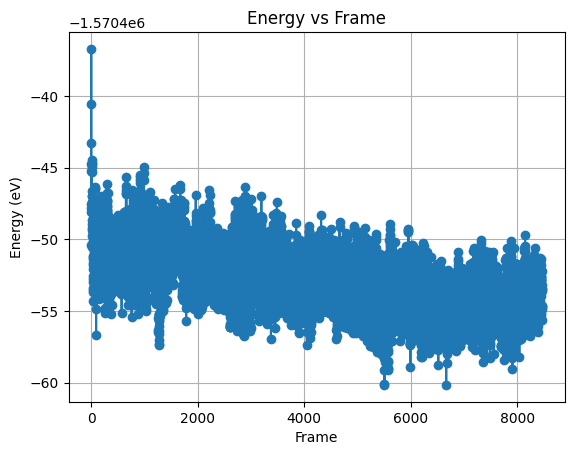

8467

In [1]:
# Load ASE trajectory
from ase.io import Trajectory
import matplotlib.pyplot as plt

# Load the trajectory
path = '/global/cfs/cdirs/m4558/first_100ps_traj_to_send/md_omol_naotf_dme_s1p1_omol.traj'
traj = Trajectory(path)

# Number of frames
n_frames = len(traj)

# Extract energies (in eV)
energies = [atoms.get_potential_energy() for atoms in traj]

# Plot energies
plt.plot(range(n_frames), energies, marker="o", linestyle="-")
plt.xlabel("Frame")
plt.ylabel("Energy (eV)")
plt.title("Energy vs Frame")
plt.grid(True)
plt.show()

n_frames


In [44]:
def plot_efs(traj):
    energies = [atoms.get_potential_energy() for atoms in traj]
    forces_norm = [atoms.get_forces().std() for atoms in traj]  # Example: std of forces per frame
    stresses = [atoms.get_stress().mean() for atoms in traj]
    indices = list(range(len(traj)))
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(indices, energies, label='Energy (eV)')
    plt.xlabel('Frame Index')
    plt.ylabel('Potential Energy (eV)')
    plt.title('Trajectory Energy vs. Frame Index')
    plt.legend()

    # plt.subplot(1, 2, 2)
    # plt.plot(indices, forces_norm, label='Forces std (eV/Å)')
    # plt.xlabel('Frame Index')
    # plt.ylabel('Std of Forces (eV/Å)')
    # plt.title('Trajectory Forces Std vs. Frame Index')
    # plt.legend()
    
    # plt.figure()
    # plt.plot(indices, stresses, label='Mean Stress')
    # plt.xlabel('Frame Index')
    # plt.ylabel('Mean Stress')
    # plt.title('Trajectory Mean Stress vs. Frame Index')
    # plt.legend()
    
    # plt.tight_layout()
    # plt.show()
    
    

In [80]:
plot_efs(molecules_val)

TypeError: Invalid type for charge: <class 'numpy.int64'>. Charge must be an integer representing the total charge on the system.

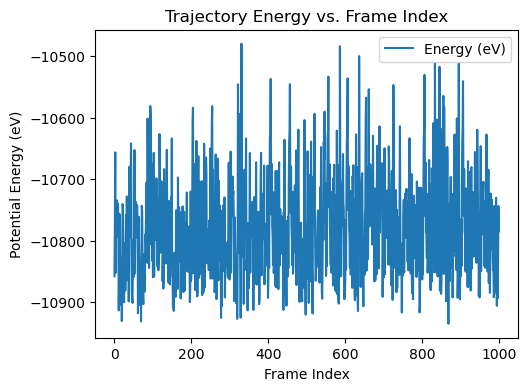

In [46]:
plot_efs(molecules_train)

In [29]:



# Get the first molecule in the list
first_mol = molecules[0]

# for atoms in molecules:
#     print(atoms.info.get('energy'))      # Per-frame energy
#     print(atoms.arrays.get('forces'))    # Per-atom forces
#     print(atoms.info.get('stress')) 
    
energy = first_mol.get_potential_energy()
forces = first_mol.get_forces()
stress = first_mol.get_stress()

print("Energy:", energy)
print("Energy 2:", first_mol.calc.results['energy'])
print("Forces (2nd atom):", forces)
print("Stress:", stress)

Energy: -1560814.7942303875
Energy 2: -1560814.7942303875
Forces (2nd atom): [[ 3.41186400e-02 -3.65269480e-01 -2.09440690e-01]
 [ 5.16849700e-01  5.97090360e-01  1.09311450e+00]
 [-1.35996437e+00 -4.08961860e-01  7.43463340e-01]
 ...
 [-3.16773000e-01 -5.68944600e-02 -3.16883650e-01]
 [ 6.02880000e-04 -5.96579790e-01  1.85217770e-01]
 [-3.68720470e-01  5.80962180e-01  5.07641970e-01]]
Stress: [ 0.00185058  0.00106476  0.00115332 -0.00073169  0.00092554 -0.00083934]


Mean energy of trajectory: -10781.647346738448


1894
Cell of first frame:
Cell([28.5579, 28.5579, 28.5579])
Number of atoms in the first frame: 2136


NGLWidget(max_frame=1893)

In [3]:
print(traj[101])

Atoms(symbols='C500H1250F102Na17O250P17', pbc=True, cell=[29.21772231237912, 28.575528421936973, 28.708999765793433], momenta=..., calculator=SinglePointCalculator(...))
